# One number on the front page

**Week 2, Friday. Round 3 of 3.** By the end of this notebook you can choose the front-page number,
give it its period, its comparison and its denominator, show its trend without letting one lumpy
segment write the story, and recompute it the moment a director changes what it covers.

> **The client asks.** "One number on the front page with its trend. If a director changes an
> assumption in the room, the sheet must recalculate in front of them."
>
> Meera's chief of staff, Kalpa Retail

> **Kavya's review.** "A number without its period is read against whatever the director remembers.
> A percentage without its base is read as whatever the director fears."

Round 1 left a tree that reconciles by segment and quarter, and round 2 a list that fails out loud.
This round turns the tree into one card.

**Setup.** The two exports and the control totals. The quarter and month are added to the raw export,
and each order is counted once, which round 1 proved reconciles.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

clean = pd.read_csv(kit.data_dir() / "C2_W02_D05_customer_table_STUDENT.csv")
raw = pd.read_csv(kit.data_dir() / "C2_W02_D05_raw_export_STUDENT.csv")
WAREHOUSE = {"Q1": 100_000_000, "Q2": 98_400_000}   # Monday's warehouse totals, from Week 2 Monday
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


print(len(clean), "customer rows and", len(raw), "export rows loaded")

raw["quarter"] = pd.to_datetime(raw.order_date).dt.month.map(lambda m: "Q1" if m <= 6 else "Q2")
raw["month"] = pd.to_datetime(raw.order_date).dt.strftime("%b")
orders = raw.drop_duplicates("order_id")
by_q = orders.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum")
print(crore(by_q.Q1.sum()), "in Q1 and", crore(by_q.Q2.sum()), "in Q2")

300 customer rows and 1450 export rows loaded
Rs 10.00 crore in Q1 and Rs 9.84 crore in Q2


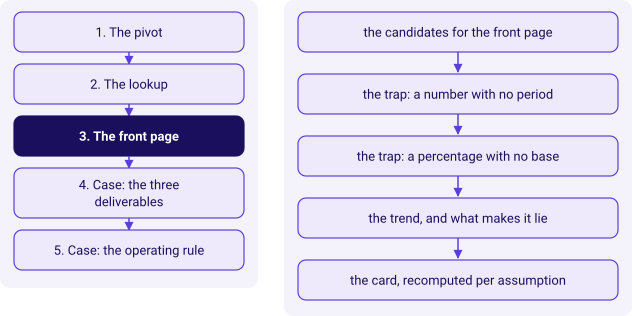

In [2]:
kit.side_by_side(
    kit.ladder(['The pivot', 'The lookup', 'The front page', 'Case: the three deliverables', 'Case: the operating rule'], lit=2, show=False),
    kit.vflow(['the candidates for the front page', 'the trap: a number with no period', 'the trap: a percentage with no base', 'the trend, and what makes it lie', 'the card, recomputed per assumption'], show=False),
)

## 1. Which number goes on the front page

Meera's question since Week 1 is where growth comes from and where it leaks. The front page carries
one number that answers the first half and points at the second.

**Predict before you run.** Which is the front-page number for Monday's growth review? a) revenue
across both quarters, the biggest; b) Q2 revenue against Q1; c) the number of customers; d) Retail-Plus
orders per member.

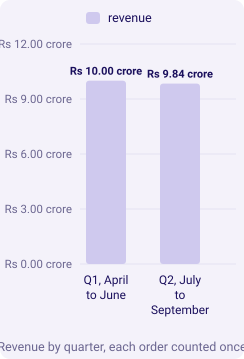

In [3]:
q1, q2 = int(by_q.Q1.sum()), int(by_q.Q2.sum())
kit.stats([(crore(q1 + q2), "both quarters", "April to September"),
           (crore(q2), "Q2 revenue", "July to September"),
           (f"{(q2 - q1) / q1:+.1%}", "Q2 on Q1", "the trend Meera asked about")])
kit.columns(["Q1, April to June", "Q2, July to September"], [("revenue", [q1, q2])], fmt=crore,
            title="Revenue by quarter, each order counted once")

**What happened.** The answer is b. The growth review asks what moved, so the number is the latest
quarter against the one before: Rs 9.84 crore in Q2, down 1.6 percent on Rs 10.00 crore in Q1.
Option d is the finding under it, which the sentence beside the number carries.

In [4]:
kit.check("Q2 matches Monday's warehouse number", q2 == WAREHOUSE["Q2"], crore(q2))
kit.check("Q2 fell against Q1", q2 < q1, f"{(q2 - q1) / q1:+.2%}")

## 2. The trap: a number with no period

**The plausible wrong answer.** The fastest card is the grand total of the customer table in big
type: **Revenue Rs 19.84 crore.**

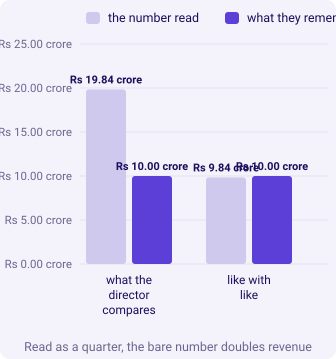

In [5]:
bare = int(clean.revenue.sum())
kit.stats([(crore(bare), "Revenue", "the card as drafted, with nothing beside it")])
kit.columns(["what the director compares", "like with like"],
            [("the number read", [bare, q2]), ("what they remember for Q1", [q1, q1])], fmt=crore,
            title="Read as a quarter, the bare number doubles revenue")

**Why it is wrong.** A director who remembers Rs 10.00 crore for Q1 reads Rs 19.84 crore as this
quarter and says revenue nearly doubled, and the growth review celebrates a quarter in which revenue
fell. The number is two quarters added together, and nothing on the card says so. The check is to
read the card aloud and ask "which months?" and "against what?"; if the card cannot answer, it is not
ready. The fix names the period and the comparison on the card itself.

In [6]:
card = f"Q2, July to September 2026: {crore(q2)}, down {abs(q2 - q1) / q1:.1%} on Q1, April to June 2026 ({crore(q1)})"
print(card)
kit.check("the bare number is roughly two quarters", abs(bare / q2 - 2) < 0.05, f"{bare / q2:.2f} times Q2")
kit.check("the fixed card names its months", "July to September" in card and "April to June" in card)

Q2, July to September 2026: Rs 9.84 crore, down 1.6% on Q1, April to June 2026 (Rs 10.00 crore)


## 3. The trap: a percentage with no base

The tree says the fall sits in Retail-Plus, so the draft card for the second slot is the segment's
change.

**Predict before you run.** "Retail-Plus revenue down 29.4 percent." What does a director hear? a) a
small tier had a bad quarter; b) the business is collapsing; c) nothing, a percentage is complete; d)
that Business fell too.

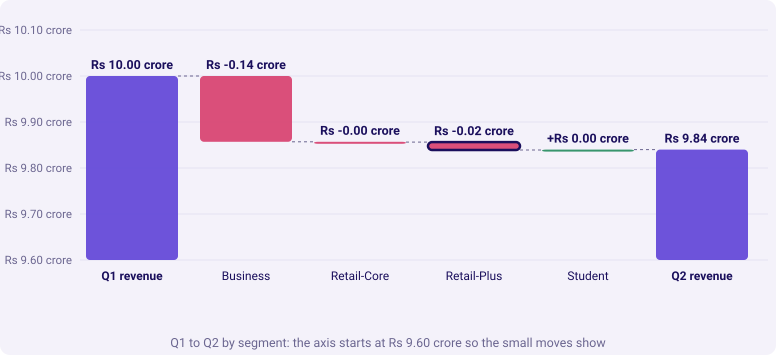

In [7]:
p1, p2 = int(by_q.Q1["Retail-Plus"]), int(by_q.Q2["Retail-Plus"])
kit.stats([(f"{(p2 - p1) / p1:.1%}", "Retail-Plus, the card as drafted", "no base, no share"),
           (lakh(p1 - p2), "what the fall is in rupees", f"on a {crore(q1)} quarter"),
           (f"{p2 / q2:.1%}", "Retail-Plus's share of Q2", "the denominator the card left out")])
moves = [(s, int(by_q.Q2[s] - by_q.Q1[s])) for s in ["Business", "Retail-Core", "Retail-Plus", "Student"]]
kit.bridge(("Q1 revenue", q1), moves, end_label="Q2 revenue", fmt=crore, lo=96_000_000, lit=[2],
           title="Q1 to Q2 by segment: the axis starts at Rs 9.60 crore so the small moves show")

**What happened.** The answer is b, and that is the trap. The 29.4 percent is real, and it is 29.4
percent of Rs 5.86 lakh, a segment worth 0.4 percent of the quarter. The rupee fall of the whole
company is mostly Business, which moves in lumps of corporate invoices. Read without its base, the card
sends the room to rescue the wrong thing, or to panic. The check is to put the rupee base and the share
beside every percentage. A second check catches a formula slip that makes it worse: a change divided by
the current quarter instead of the earlier one.

In [8]:
right = (p2 - p1) / p1
wrong_base = (p2 - p1) / p2
kit.table(["How the change is computed", "Retail-Plus, Q1 to Q2"],
          [("on the earlier quarter, (Q2 - Q1) / Q1", f"{right:.1%}"),
           ("on the current quarter, (Q2 - Q1) / Q2", f"{wrong_base:.1%}")],
          caption="The base of a change is the period you are comparing against")
plus_card = (f"Retail-Plus, Q2, July to September 2026: {lakh(p2)}, down {abs(right):.1%} on Q1 ({lakh(p1)}); "
             f"{p2 / q2:.1%} of company revenue")
print(plus_card)
kit.check("the change on the wrong base overstates the fall", abs(wrong_base) > abs(right),
          f"{wrong_base:.1%} against {right:.1%}")
kit.check("Retail-Plus is under one percent of the quarter", p2 / q2 < 0.01, f"{p2 / q2:.2%}")

How the change is computed,"Retail-Plus, Q1 to Q2"
"on the earlier quarter, (Q2 - Q1) / Q1",-29.4%
"on the current quarter, (Q2 - Q1) / Q2",-41.7%


Retail-Plus, Q2, July to September 2026: Rs 4.13 lakh, down 29.4% on Q1 (Rs 5.86 lakh); 0.4% of company revenue


## 4. The trend, and what makes it lie

The chief of staff wants the number **with its trend**. Month by month, the company line is Business's
invoices, and a consumer segment's drift is invisible under it.

**Predict before you run.** July's company revenue is 45 percent above June's. Is July growth? a)
yes, the best month of the half-year; b) no, one segment's invoices landed in it; c) yes, the monsoon
sale worked; d) it cannot be told from months.

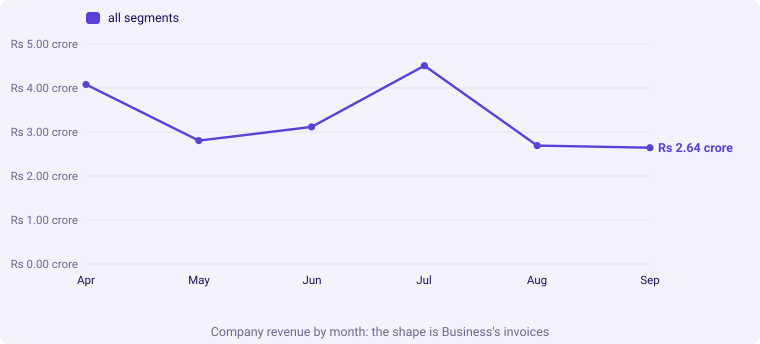

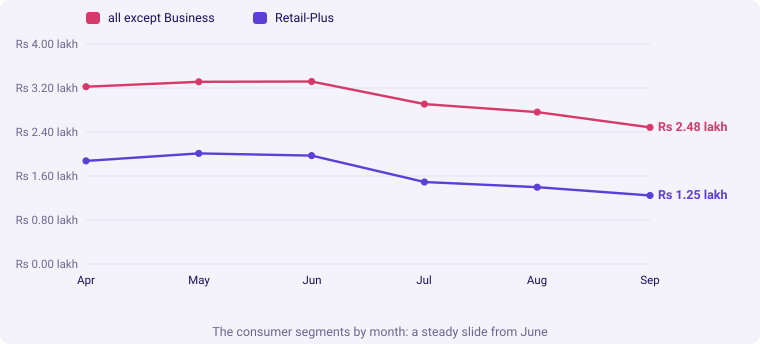

In [9]:
order = ["Apr", "May", "Jun", "Jul", "Aug", "Sep"]
monthly = orders.pivot_table(index="month", columns="segment", values="order_amount", aggfunc="sum").reindex(order)
company = monthly.sum(axis=1)
consumer = company - monthly["Business"]
kit.line(order, [("all segments", [int(v) for v in company], "plain")], fmt=crore,
         title="Company revenue by month: the shape is Business's invoices")
kit.line(order, [("all except Business", [int(v) for v in consumer], "bad"),
                 ("Retail-Plus", [int(v) for v in monthly["Retail-Plus"]], "plain")], fmt=lakh,
         title="The consumer segments by month: a steady slide from June")

**What happened.** The answer is b. Business's corporate invoices land in lumps, so the company line
jumps in April and July and tells you when invoices were booked. Take Business out and the consumer
revenue falls in each of the last three months, from Rs 3.32 lakh in June to Rs 2.48 lakh in
September, and Retail-Plus carries most of that fall. So the trend beside the front-page number is
the consumer line, labelled as such.

In [10]:
kit.check("July looks like growth on the company line", company["Jul"] > company["Jun"] * 1.3,
          f"{company['Jul'] / company['Jun'] - 1:+.0%}")
kit.check("the consumer line falls every month from June", consumer["Jul"] < consumer["Jun"] and
          consumer["Aug"] < consumer["Jul"] and consumer["Sep"] < consumer["Aug"])

## 5. The card, recomputed when a director changes an assumption

A director says, "Take Business out, it is lumpy." Another says, "Show me Retail-Plus." The card has to
recompute its number, its comparison and its denominator from the same source, which is what the
yellow scope cell on the deck pack's FrontPage tab does. Here the card is one function.

All segments, Q2, July to September 2026: Rs 9.84 crore, down 1.6% on Q1 (Rs 10.00 crore); 100.0% of company revenue
All except Business, Q2, July to September 2026: Rs 8.15 lakh, down 17.3% on Q1 (Rs 9.86 lakh); 0.8% of company revenue
Retail-Plus, Q2, July to September 2026: Rs 4.13 lakh, down 29.4% on Q1 (Rs 5.86 lakh); 0.4% of company revenue


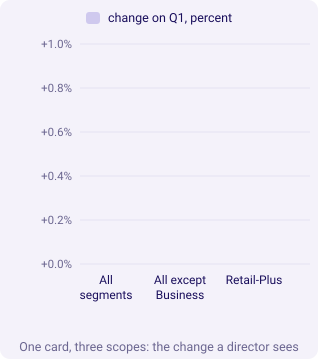

In [11]:
def card_for(scope):
    """The front-page card for a scope, computed from the orders, never typed."""
    if scope == "All segments":
        a, b = q1, q2
    elif scope == "All except Business":
        a, b = q1 - int(by_q.Q1["Business"]), q2 - int(by_q.Q2["Business"])
    else:
        a, b = int(by_q.Q1[scope]), int(by_q.Q2[scope])
    money = crore if b >= 1e7 else lakh
    word = "down" if b < a else "up"
    return (f"{scope}, Q2, July to September 2026: {money(b)}, {word} {abs(b - a) / a:.1%} on Q1 "
            f"({money(a)}); {b / q2:.1%} of company revenue"), (b - a) / a


cards = {s: card_for(s) for s in ["All segments", "All except Business", "Retail-Plus"]}
for s, (text, _) in cards.items():
    print(text)
kit.columns(list(cards), [("change on Q1, percent", [round(c * 100, 1) for _, c in cards.values()])],
            fmt=lambda v: f"{v:+.1f}%", title="One card, three scopes: the change a director sees")

In [12]:
kit.check("taking Business out turns a 1.6 percent fall into a 17.3 percent fall",
          round(cards["All except Business"][1] * 100, 1) == -17.3, f"{cards['All except Business'][1]:.1%}")
kit.check("every card carries its period, its comparison and its share",
          all("July to September" in t and "on Q1" in t and "of company revenue" in t for t, _ in cards.values()))

> **Kavya's review.** "Read the card aloud to someone who has not seen the sheet. If they ask which
> months, against what, or out of how much, the card answers on its face or it goes back."

### In the interview

**[F] How do you present one number so it is not misread?** With four things beside it: the period it
covers, the comparison it moved against, the base or share that says how big it is, and one sentence
saying what it means for the decision. "Q2, July to September: Rs 9.84 crore, down 1.6 percent on
Q1's Rs 10.00 crore; the fall sits in Retail-Plus, where orders per member fell from 2.36 to 1.84."
A bare Rs 19.84 crore gets read as a doubled quarter; a bare 29.4 percent gets read as a collapse.

**[D] Two directors change assumptions in the room and the sheet recalculates differently for each.
What did you get right, and what do you fix?** What I got right: the assumptions are inputs, and every
number recomputes from the same source, so both answers are honest for their assumptions. What I fix:
the card must say which assumption it is showing, so the two answers are never compared as if they
were one number. Taking Business out moves the change from minus 1.6 to minus 17.3 percent, and the
scope has to be printed on the card, which is why the deck pack writes it into the sentence.

### Depth: why the trend is a line of months and the number is a quarter

The front-page number is a quarter because Finance closes quarters and the warehouse reconciles them.
The trend is monthly because three points in a quarter show a direction a single change cannot. Both
come from the same orders, so they cannot disagree, and the card's check ties the two quarters of the
trend back to the warehouse.

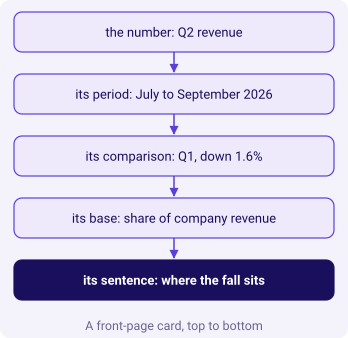

What this round established,The number
the front-page number,"Q2 Rs 9.84 crore, down 1.6 percent on Q1"
"the bare total, read as a quarter",Rs 19.84 crore
Retail-Plus with no base,"down 29.4 percent, 0.4 percent of the quarter"
the same change on the wrong base,41.7 percent
"all except Business, the director's scope",down 17.3 percent


In [13]:
kit.vflow(["the number: Q2 revenue", "its period: July to September 2026", "its comparison: Q1, down 1.6%",
           "its base: share of company revenue", "its sentence: where the fall sits"], lit=4,
          title="A front-page card, top to bottom")
kit.table(["What this round established", "The number"],
          [("the front-page number", "Q2 Rs 9.84 crore, down 1.6 percent on Q1"),
           ("the bare total, read as a quarter", "Rs 19.84 crore"),
           ("Retail-Plus with no base", "down 29.4 percent, 0.4 percent of the quarter"),
           ("the same change on the wrong base", "41.7 percent"),
           ("all except Business, the director's scope", "down 17.3 percent")])
kit.check_summary()

The afternoon runs the three deliverables end to end on the escalated case, then defends the operating
rule against a director who wants to edit the source.